In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing

In [2]:
housing = fetch_california_housing()

In [3]:
housing.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

In [4]:
print(housing["DESCR"])

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [5]:
housing["target_names"]

['MedHouseVal']

In [6]:
df = pd.DataFrame(housing["data"], columns = housing["feature_names"])
df["MedHouseVal"] = housing["target"]
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
MedHouseVal,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


In [9]:
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

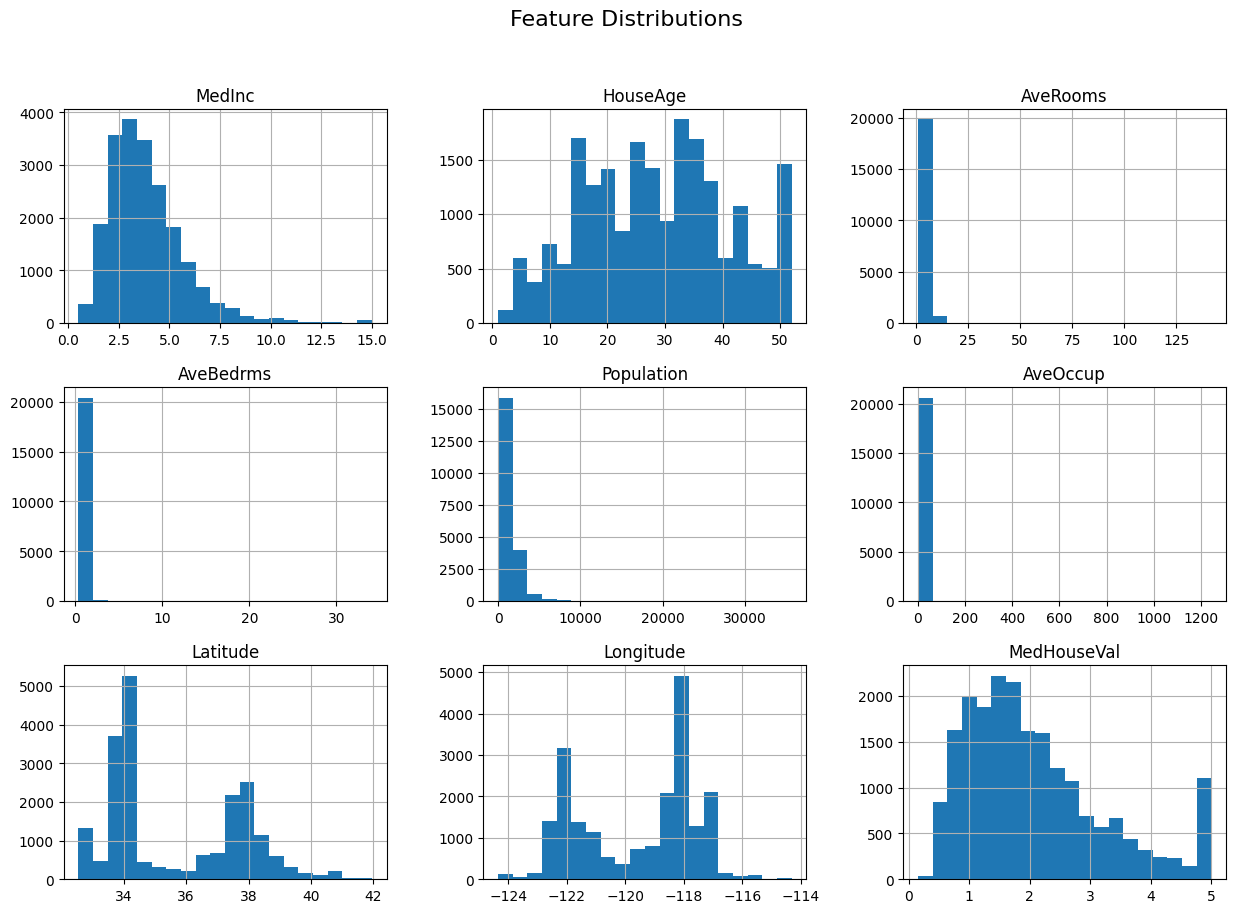

In [10]:
df.hist(bins =20, figsize =(15,10))
plt.suptitle("Feature Distributions", fontsize =16);

In [11]:
df.corr()["MedHouseVal"].sort_values(ascending= False)

MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64

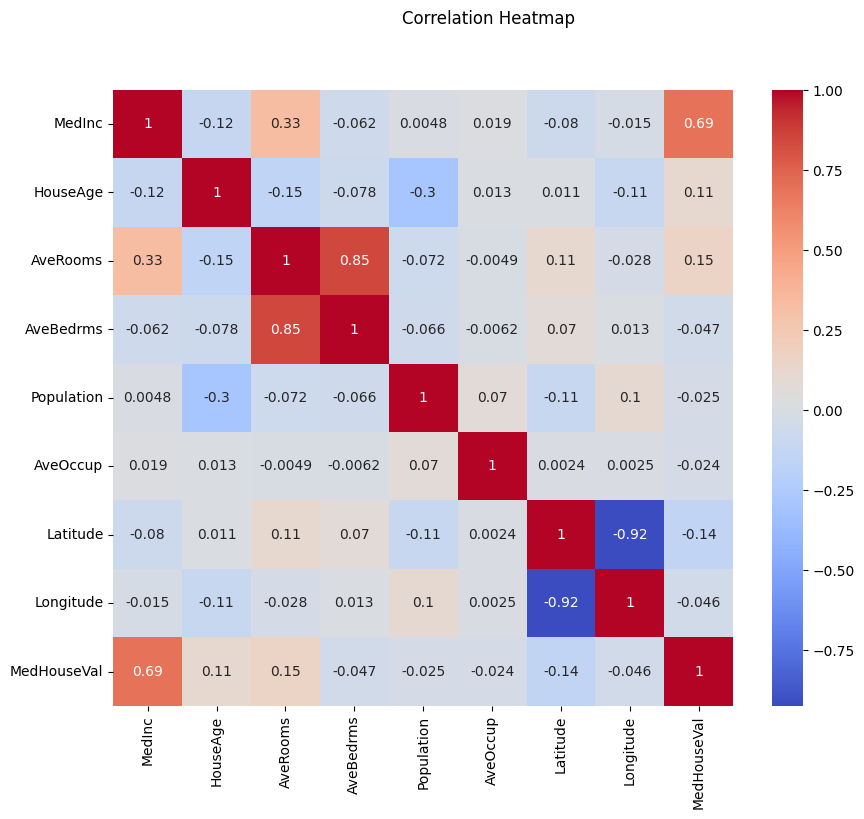

In [12]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot =True,cmap= "coolwarm")
plt.suptitle("Correlation Heatmap");

In [13]:
from sklearn.model_selection import train_test_split,cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor

In [14]:
df.head(3)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521


In [15]:
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

In [16]:
print('df shape',df.shape)
print('X features',X.shape)
print('y target',y.shape)

df shape (20640, 9)
X features (20640, 8)
y target (20640,)


In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2, 
                                                    random_state=101)

In [18]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(16512, 8) (16512,)
(4128, 8) (4128,)


In [38]:
# Build baseline

from sklearn.dummy import DummyRegressor
dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)
dummy_rmse = np.sqrt(mean_squared_error(y_test, y_pred_dummy))
dummy_r2 = r2_score(y_test, y_pred_dummy)
dummy_mape= mean_absolute_percentage_error(y_test, y_pred_dummy)
print('-- Dummy Regressor metrics--')
print('dummy_r2:',dummy_r2)
print('dummy_rmse    :', dummy_rmse)
print('dummy_mape    :', dummy_mape*100)

-- Dummy Regressor metrics--
dummy_r2: -0.00011623575669661435
dummy_rmse    : 1.1627691181408848
dummy_mape    : 61.93813711029688


In [19]:

knn_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsRegressor())
])

param_grid = {'knn__n_neighbors' : range(1,21)}

grid = GridSearchCV(knn_pipe, param_grid, cv=5, scoring='r2')
grid.fit(X_train, y_train)

best_k = grid.best_params_['knn__n_neighbors']
print("Best n_neighbors:", best_k)
print("BestCV R²:", grid.best_score_)

best_knn = grid.best_estimator_
print("Test R²:", best_knn.score(X_test, y_test))

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error

y_pred_knn = grid.best_estimator_.predict(X_test)
knn_r2 = r2_score(y_test, y_pred_knn)
knn_rmse = np.sqrt(mean_squared_error(y_test, y_pred_knn))
knn_mape = mean_absolute_percentage_error(y_test, y_pred_knn)

results = {
    'KNN': {'R2': knn_r2, 'RMSE': knn_rmse, 'best_params': best_k}
}

print ('\n---KNN Regressor Metrics---')
print('knn_r2_score:',knn_r2)
print('knn_rmse    :', knn_rmse)
print('knn_mape    :', knn_mape*100)

Best n_neighbors: 14
BestCV R²: 0.7015289244363595
Test R²: 0.6831087688588182

---KNN Regressor Metrics---
knn_r2_score: 0.6831087688588182
knn_rmse    : 0.6545206619674193
knn_mape    : 23.91631259607276


- **n_neighbors** → the hyperparameter of the KNN model.
- controls how many neighbors are considered when making predictions.
-  optimize with (e.g., test values from 1 to 20) to find the best fit for the dataset.
-  Inside GridSearchCV, which parameter needs to be tuned is in format : ```stepname__parametername```
- knn - name of step in pipeline, n _neighbors- parameter of KNeighborsRegressor , together : knn__n_neighbors
- r2 (R-squared) as scoring metric is how well your **model explains the variance in your target data**. & standard choice for regression problems because it provides an easily interpretable(typically ranges from 0 to 1, negative implies terrible gutssing avg values), relative scale of performance. Other scores MAE, MSE
- Lat and lon have strong signal, but KNN can't exploit it effectively because Euclidean distance in coordinate space doesn't reflect real geographic or economic boundaries

| Metric | Value | What it says |
|--------|-------|--------------|
| R² | 0.683 | Model explains 68.3% of variance in prices |
| RMSE | $65,450 | Average prediction is off by this dollar amount |
| MAPE | run it | Average prediction is off by X% of actual value |

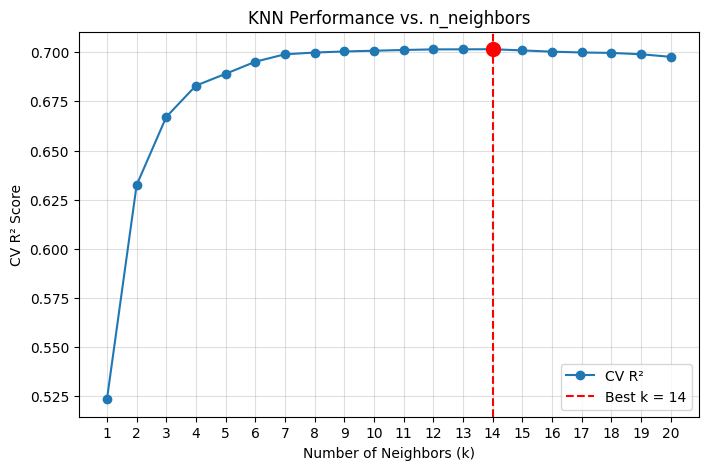

In [20]:
# Plot best K for the iterations
results = grid.cv_results_
neighbors = results['param_knn__n_neighbors']
scores = results['mean_test_score']

# Find best neighbor and score
best_k = grid.best_params_['knn__n_neighbors']
best_score = grid.best_score_

plt.figure(figsize=(8,5))
plt.plot(neighbors, scores, marker='o', label="CV R²")

# Highlight the best point
plt.axvline(best_k, color='red', linestyle='--', label=f"Best k = {best_k}")
plt.scatter(best_k, best_score, color='red', s=100, zorder=5)

# Axis labels and title
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("CV R² Score")
plt.title("KNN Performance vs. n_neighbors")
plt.xticks(range(min(neighbors), max(neighbors)+1, 1))  # step of 1
plt.grid(alpha =0.4)
plt.legend()
plt.show()


In [32]:
from sklearn.linear_model import LinearRegression, RidgeCV

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
     ('linearreg', LinearRegression())
     ])
lr_pipe.fit(X_train, y_train)
y_pred_lr = lr_pipe.predict(X_test)

lr_r2 = r2_score(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test,y_pred_lr))
lr_mape = mean_absolute_percentage_error(y_test, y_pred_lr)
                  
print('-- Linear Regression metrics--')
print('linreg_r2_score:',lr_r2)
print('linreg_rmse    :', lr_rmse)
print('linreg_mape    :', lr_mape*100)
                 

-- Linear Regression metrics--
linreg_r2_score: 0.5970946680312593
linreg_rmse    : 0.7380227636627963
linreg_mape    : 31.278817563873005


In [36]:
ridge_cv = Pipeline([
    ('scaler',StandardScaler()),
    ('ridgecv',RidgeCV())
])

ridge_cv.fit(X_train, y_train)
y_pred_rcv= ridge_cv.predict(X_test)

ridge_cv_r2 =r2_score(y_test,y_pred_rcv)
ridge_cv_rmse= np.sqrt(mean_squared_error(y_test, y_pred_rcv))
ridge_cv_mape =mean_absolute_percentage_error(y_test, y_pred_rcv)

print('-- Ridge CV metrics--')
print('ridgeCV_r2:',ridge_cv_r2)
print('ridgeCV_rmse    :', ridge_cv_rmse)
print('ridgeCV_mape    :', ridge_cv_mape*100)



-- Ridge CV metrics--
ridgeCV_r2: 0.5969716587342676
ridgeCV_rmse    : 0.7381354163456778
ridgeCV_mape    : 31.278880862204556


## Findings

- Dummy Regressor - establishes as baseline, with negative R2, meaning worse than predicting mean.
- KNN Regressor(k =14) outperforms in all three metrics,KNN MAPE is 23.9% vs LinearReg MAPE 31.3%, ie KNN is off on $100 house value by 24 dollars versus linear model off by ~31 dollars
- Linear Regression and Ridge CV perform better than dummy , but are identical but underperform vs KNN
- the feature-target relationships are non-linear, so a parametric linear model underfits where KNN's neighborhood averaging captures local patterns better.    